# Experiment: Supplement: c_BE Alignment and Theory Comparison

Objective:
- Step 1: measure the deterministic speed law $v_E = d\theta_E/dt$ as a function of sustained constant $c_{BE}$.
- Step 2: identify the $c_{BE}$ range where the bump and edge remain effectively aligned.
- Step 3: construct a numerical $c_{BE}(\theta)$ for a target constant latent-space speed $v_{x_E} = dx_E/dt$.
- Step 4: compare the implementation-derived profile against the manuscript Eq. 18 approximation.

Success criteria:
- The notebook stays on the tested parameter configuration already used in `figures_code/supp/c_be_velocity_calibration.ipynb`.
- The notebook reports a concrete alignment-preserving `c_BE` interval rather than a qualitative statement.
- The notebook produces a direct overlay between the derived `c_BE(theta)` profile and its Eq. 18 comparison.


In [2]:
from __future__ import annotations

import runpy
from pathlib import Path

_NOTEBOOK_SETUP = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    helper = candidate / "figures_code" / "notebook_setup.py"
    if helper.exists():
        _NOTEBOOK_SETUP = runpy.run_path(str(helper))
        break
if _NOTEBOOK_SETUP is None:
    raise RuntimeError("Could not locate figures_code/notebook_setup.py")

REPO_ROOT = _NOTEBOOK_SETUP["REPO_ROOT"]

import matplotlib.pyplot as plt
import numpy as np

from CANN_DDM_model_rate_based import CANN_DDM_model
from rate_model_core.default_params import build_stable_default_params

SEED = 4
np.random.seed(SEED)
REPO_ROOT


PosixPath('/projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model')

## Baseline configuration and notebook plan

This notebook intentionally reuses the same tested baseline configuration as `figures_code/supp/c_be_velocity_calibration.ipynb` and changes only the analysis scope.

Notebook choices:
- keep the same geometry, edge, and bump parameters
- set all cue trains to zero
- set population noise to zero
- replace cue-gated `I_BE` by a sustained constant drive with amplitude `c_BE`
- define the trusted theory-comparison regime using numerical alignment diagnostics rather than assuming it a priori

The resulting notebook is a companion analysis: it extends the earlier calibration notebook instead of replacing it.


In [3]:
def build_baseline_params(*, c_be: float = 0.0, x0: float = 0.5) -> dict:
    params = build_stable_default_params()
    params['bump_pop']['c_BE'] = float(c_be)
    params['bump_pop']['noise_scale_bump'] = 0.0
    params['edge_pop']['noise_scale_edge'] = 0.0
    params['decision_space_params']['x0'] = float(x0)
    return params


class ConstantDriveIBEModel(CANN_DDM_model):
    """Interpret the scalar c_BE as a sustained post-onset bump-to-edge drive."""

    def get_current_I_BE(self, cue_R, cue_L, r_B, c_BE):
        filtered_r_B = self.W_BE @ r_B
        return c_BE * filtered_r_B



def make_model(*, c_be: float, x0: float = 0.5) -> ConstantDriveIBEModel:
    model = ConstantDriveIBEModel(CANN_params=build_baseline_params(c_be=c_be, x0=x0))
    model.cue_R_all[:] = 0.0
    model.cue_L_all[:] = 0.0
    return model


base_model = make_model(c_be=0.0)
THETA_SPACING = float((base_model.theta_max - base_model.theta_min) / (base_model.num_E - 1))
GAMMA_THEORY = float(base_model.gamma_E)
{
    'theta_min': float(base_model.theta_min),
    'theta_max': float(base_model.theta_max),
    'coding_theta_min': float(base_model.coding_theta_min),
    'coding_theta_max': float(base_model.coding_theta_max),
    'theta_spacing': THETA_SPACING,
    'gamma_theory': GAMMA_THEORY,
}

MIN_ACCUMULATION_SAMPLES = 200

THETA_MARGIN = 0.02

## Mapping and helper functions

The live code now implements a finite-interval normalized monotone `x(\theta)` mapping through `pos_to_evidence()`, sending the coding-window endpoints exactly onto the evidence-domain endpoints. The derived $c_{\mathrm{BE}}(\theta)$ construction below uses that implementation mapping directly.

For the theory comparison:
- the derived $c_{\mathrm{BE}}(\theta)$ is constructed from the measured small-signal gain and the implementation mapping $dx/d\theta$.
- Eq. 18 is treated as the relevant manuscript comparison because the construction above is already a small-signal exponential law.
- the comparison is fit only inside the trusted alignment-preserving region and then shown both inside and outside that regime.


(-1.5707963267948966, 1.5707963267948966)

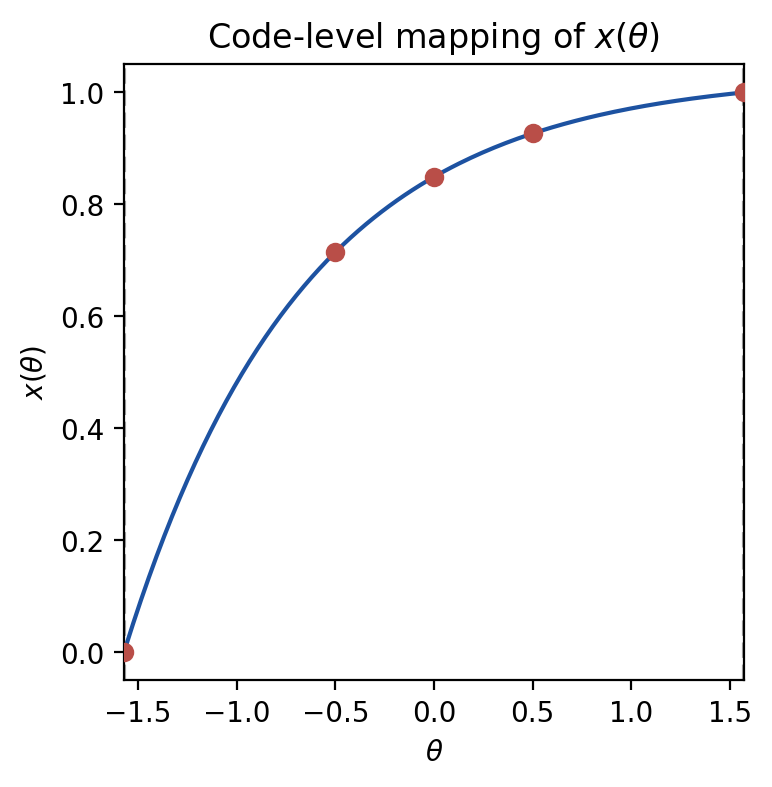

In [4]:
def estimate_slope(times: np.ndarray, values: np.ndarray, window: tuple[float, float]) -> float:
    start, stop = window
    mask = (times >= start) & (times <= stop)
    if np.count_nonzero(mask) < 2:
        return float('nan')
    slope, _ = np.polyfit(times[mask], values[mask], deg=1)
    return float(slope)


def count_window_samples(times: np.ndarray, window: tuple[float, float]) -> int:
    start, stop = window
    return int(np.count_nonzero((times >= start) & (times <= stop)))


def accumulation_fit_window(times: np.ndarray, *, t_start: float, boundary_index: int | None) -> tuple[float, float]:
    stop = float(times[boundary_index]) if boundary_index is not None else float(times[-1])
    return float(t_start), stop


def run_constant_drive_trial(c_be: float, *, x0: float = 0.5) -> dict:
    model = make_model(c_be=c_be, x0=x0)
    runner = model.run_simulation(
        mon_vars=['theta_E', 'theta_B', 'x_E', 'x_B', 'I_BE', 'I_EB', 'hit_boundary'],
        progress_bar=False,
        dt=1.0,
        get_RT=False,
    )

    times = np.arange(len(runner.mon.theta_E), dtype=float)
    theta_e = np.asarray(runner.mon.theta_E).reshape(-1)
    theta_b = np.asarray(runner.mon.theta_B).reshape(-1)
    x_e = np.asarray(runner.mon.x_E).reshape(-1)
    x_b = np.asarray(runner.mon.x_B).reshape(-1)
    hit = np.asarray(runner.mon.hit_boundary).reshape(-1)
    hit_indices = np.flatnonzero(hit)
    boundary_index = int(hit_indices[0]) if hit_indices.size else None
    fit_window = accumulation_fit_window(times, t_start=float(model.t_start), boundary_index=boundary_index)
    accumulation_sample_count = count_window_samples(times, fit_window)
    abs_delta = np.abs(theta_b - theta_e)
    abs_delta_pre_boundary = abs_delta[:boundary_index] if boundary_index is not None else abs_delta
    if abs_delta_pre_boundary.size:
        alignment_mean_abs = float(np.mean(abs_delta_pre_boundary))
        alignment_std_abs = float(np.std(abs_delta_pre_boundary))
    else:
        alignment_mean_abs = float('nan')
        alignment_std_abs = float('nan')

    return {
        'c_BE': float(c_be),
        'times': times,
        'theta_E': theta_e,
        'theta_B': theta_b,
        'x_E': x_e,
        'x_B': x_b,
        'v_theta_E': estimate_slope(times, theta_e, fit_window),
        'v_theta_B': estimate_slope(times, theta_b, fit_window),
        'v_x_E': estimate_slope(times, x_e, fit_window),
        'v_x_B': estimate_slope(times, x_b, fit_window),
        'alignment_mean_abs': alignment_mean_abs,
        'alignment_std_abs': alignment_std_abs,
        'hit_boundary': bool(np.any(hit)),
        'boundary_index': boundary_index,
        'boundary_time_ms': float(times[boundary_index]) if boundary_index is not None else None,
        'RT_ms': float(times[boundary_index] - model.t_start) if boundary_index is not None else None,
        't_start_ms': float(model.t_start),
        'accumulation_sample_count': accumulation_sample_count,
        'alignment_sample_count': int(abs_delta_pre_boundary.size),
        'fit_window': fit_window,
    }


def build_alignment_mask(accumulation_sample_counts, alignment_mean_abs_vals, alignment_std_abs_vals):
    required_sample_count = MIN_ACCUMULATION_SAMPLES
    mean_abs_tol = 3.0 * THETA_SPACING
    std_abs_tol = 2.0 * THETA_SPACING

    valid_mask = (
        (accumulation_sample_counts >= required_sample_count)
        & (alignment_mean_abs_vals <= mean_abs_tol)
        & (alignment_std_abs_vals <= std_abs_tol)
    )
    return valid_mask, {
        'required_sample_count': int(required_sample_count),
        'mean_abs_tol': mean_abs_tol,
        'std_abs_tol': std_abs_tol,
    }

def fit_eq18_amplitude(theta_fit: np.ndarray, c_fit: np.ndarray, *, gamma_theory: float) -> float:
    basis = np.exp(gamma_theory * theta_fit)
    return float(np.dot(basis, c_fit) / np.dot(basis, basis))


def contiguous_true_regions(mask: np.ndarray) -> list[tuple[int, int]]:
    mask = np.asarray(mask, dtype=bool)
    regions = []
    start = None
    for idx, flag in enumerate(mask):
        if flag and start is None:
            start = idx
        elif (not flag) and start is not None:
            regions.append((start, idx - 1))
            start = None
    if start is not None:
        regions.append((start, len(mask) - 1))
    return regions


theta_map = np.linspace(base_model.theta_min, base_model.theta_max, 800)
x_map = np.asarray(base_model.pos_to_evidence(theta_map, base_model.gamma_E), dtype=float)
theta_min_impl = float(base_model.theta_min)
theta_max_impl = float(base_model.theta_max)
interval_impl = theta_max_impl - theta_min_impl
normalization_impl = 1.0 - np.exp(-float(base_model.gamma_E) * interval_impl)
log_linearized_map = 1.0 - normalization_impl * x_map / float(base_model.boundary)

theta_samples = np.array([
    base_model.theta_min,
    base_model.coding_theta_min,
    -0.5,
    0.0,
    0.5,
    base_model.coding_theta_max,
    base_model.theta_max,
], dtype=float)
x_samples = np.asarray(base_model.pos_to_evidence(theta_samples, base_model.gamma_E), dtype=float)

fig, ax = plt.subplots(1, 1, figsize=(4,4 ))
ax.plot(theta_map, x_map, color='#1d52a1')
ax.scatter(theta_samples, x_samples, color='#b94e48', zorder=3)
ax.axvline(base_model.coding_theta_min, color='grey', linestyle='--', alpha=0.7)
ax.axvline(base_model.coding_theta_max, color='grey', linestyle='--', alpha=0.7)
ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$x(\theta)$')
ax.set_title(r'Code-level mapping of $x(\theta)$')
ax.set_xlim(base_model.coding_theta_min, base_model.coding_theta_max)





## Step 1 and Step 2: sweep $c_{\mathrm{BE}}$, measure $v_{\mathrm{E}}(c_{\mathrm{BE}})$, and detect the alignment-preserving range

The alignment rule is intentionally explicit. For each trial, the phase-difference summaries are computed only over the samples before the first boundary hit, using the absolute phase gap $|\theta_{\mathrm{B}}-\theta_{\mathrm{E}}|$. The reported velocities $v_{\mathrm{E}}$ and $v_{\mathrm{B}}$ are fit only over the evidence-accumulation interval, from $t_{\mathrm{start}}$ to $t_{\mathrm{start}} + \mathrm{RT}$, where $\mathrm{RT}$ is the first edge boundary-hit time. A sweep point is considered valid only if all of the following hold:
- the evidence-accumulation segment contains at least the minimum required number of samples
- the pre-hit mean $|\theta_{\mathrm{B}}-\theta_{\mathrm{E}}|$ stays within a few theta grid spacings
- the pre-hit standard deviation of $|\theta_{\mathrm{B}}-\theta_{\mathrm{E}}|$ stays within a few theta grid spacings

The notebook keeps every sweep point that satisfies those conditions. It does not enforce contiguity around $c_{\mathrm{BE}}=0$.


In [5]:
C_BE_SWEEP = np.linspace(-0.2, 0.2, 10)
sweep_results = [run_constant_drive_trial(c_be) for c_be in C_BE_SWEEP]

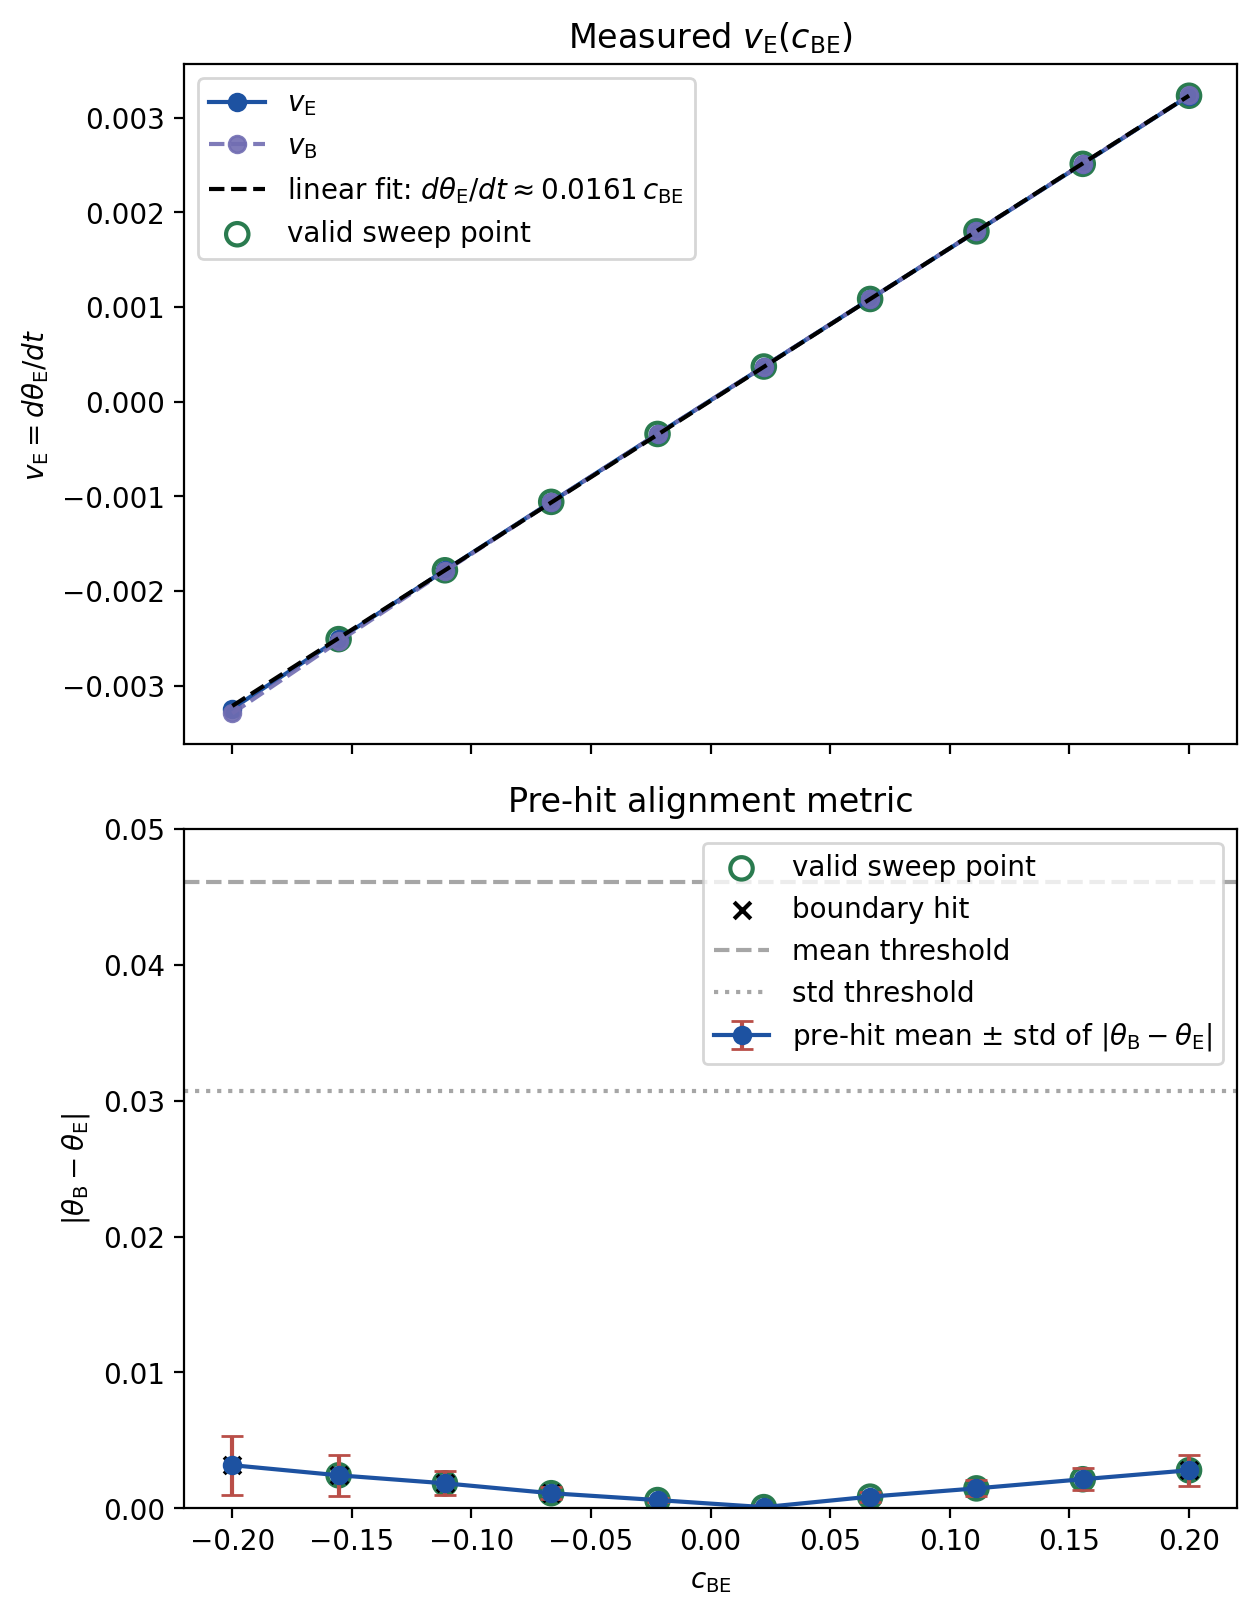

In [6]:
c_be_vals = np.array([row['c_BE'] for row in sweep_results], dtype=float)
v_theta_e_vals = np.array([row['v_theta_E'] for row in sweep_results], dtype=float)
v_theta_b_vals = np.array([row['v_theta_B'] for row in sweep_results], dtype=float)
v_x_vals = np.array([row['v_x_E'] for row in sweep_results], dtype=float)
alignment_mean_abs_vals = np.array([row['alignment_mean_abs'] for row in sweep_results], dtype=float)
alignment_std_abs_vals = np.array([row['alignment_std_abs'] for row in sweep_results], dtype=float)
boundary_hits = np.array([row['hit_boundary'] for row in sweep_results], dtype=bool)
boundary_indices = np.array([row['boundary_index'] if row['boundary_index'] is not None else -1 for row in sweep_results], dtype=int)
accumulation_sample_counts = np.array([row['accumulation_sample_count'] for row in sweep_results], dtype=int)

valid_mask, alignment_thresholds = build_alignment_mask(
    accumulation_sample_counts,
    alignment_mean_abs_vals,
    alignment_std_abs_vals,
)

fit_mask = valid_mask if np.count_nonzero(valid_mask) >= 3 else (c_be_vals <= 0.08)
gain_theta, intercept_theta = np.polyfit(c_be_vals[fit_mask], v_theta_e_vals[fit_mask], deg=1)

valid_c_be_vals = c_be_vals[valid_mask]

fig, ax = plt.subplots(2, 1, figsize=(6.4, 8.2), sharex='col')

ax[0].plot(c_be_vals, v_theta_e_vals, 'o-', color='#1d52a1', label=r'$v_{\mathrm{E}}$')
ax[0].plot(c_be_vals, v_theta_b_vals, 'o--', color='#716db2', label=r'$v_{\mathrm{B}}$', alpha=0.9)
ax[0].plot(c_be_vals, gain_theta * c_be_vals + intercept_theta, '--', color='black', label=rf'linear fit: $d\theta_{{\mathrm{{E}}}}/dt \approx {gain_theta:.3g}\, c_{{\mathrm{{BE}}}}$')
ax[0].scatter(c_be_vals[valid_mask], v_theta_e_vals[valid_mask], s=65, facecolors='none', edgecolors='#2a7b4f', linewidths=1.5, label='valid sweep point')
ax[0].set_ylabel(r'$v_{\mathrm{E}} = d\theta_{\mathrm{E}}/dt$')
ax[0].set_title(r'Measured $v_{\mathrm{E}}(c_{\mathrm{BE}})$')
ax[0].legend(loc='best')

ax[1].errorbar(
    c_be_vals,
    alignment_mean_abs_vals,
    yerr=alignment_std_abs_vals,
    fmt='o-',
    color='#1d52a1',
    ecolor='#b94e48',
    elinewidth=1.5,
    capsize=4,
    label=r'pre-hit mean $\pm$ std of $|\theta_{\mathrm{B}}-\theta_{\mathrm{E}}|$',
)
ax[1].scatter(c_be_vals[valid_mask], alignment_mean_abs_vals[valid_mask], s=65, facecolors='none', edgecolors='#2a7b4f', linewidths=1.5, label='valid sweep point')
ax[1].scatter(c_be_vals[boundary_hits], alignment_mean_abs_vals[boundary_hits], color='black', marker='x', label='boundary hit')
ax[1].axhline(alignment_thresholds['mean_abs_tol'], color='grey', linestyle='--', alpha=0.7, label=r'mean threshold')
ax[1].axhline(alignment_thresholds['std_abs_tol'], color='grey', linestyle=':', alpha=0.7, label=r'std threshold')
ax[1].set_xlabel(r'$c_{\mathrm{BE}}$')
ax[1].set_ylabel(r'$|\theta_{\mathrm{B}}-\theta_{\mathrm{E}}|$')
ax[1].set_title(r'Pre-hit alignment metric')
ax[1].legend(loc='best')
ax[1].set_ylim(0, 0.05)
plt.tight_layout()



## Step 3: numerical $c_{\mathrm{BE}}(\theta)$ for a target constant $v_{x_{\mathrm{E}}}$

Inside the alignment-preserving regime, the measured velocity law is approximately linear,

$$
\frac{d\theta_{\mathrm{E}}}{dt} \approx k_\theta c_{\mathrm{BE}}.
$$

Using the normalized implementation mapping $x(\theta)$, a target constant latent-space speed then implies

$$
\frac{dx_{\mathrm{E}}}{dt} = \frac{dx}{d\theta} \frac{d\theta_{\mathrm{E}}}{dt} \approx \frac{dx}{d\theta} k_\theta c_{\mathrm{BE}}(\theta).
$$

The next cell computes this numerical coupling profile and marks theta values whose required $c_{\mathrm{BE}}(\theta)$ is closest to a valid swept $c_{\mathrm{BE}}$ point, without assuming the valid sweep set is contiguous.


In [21]:
TARGET_VX = 1.0e-4

{'target_v_x': 0.0001,
 'trusted_theta_regions': [(-1.5507963267948965, 1.5507963267948965)],
 'numerical_c_BE_min': 0.0055834964736693376,
 'numerical_c_BE_max': 0.16928219364933744}

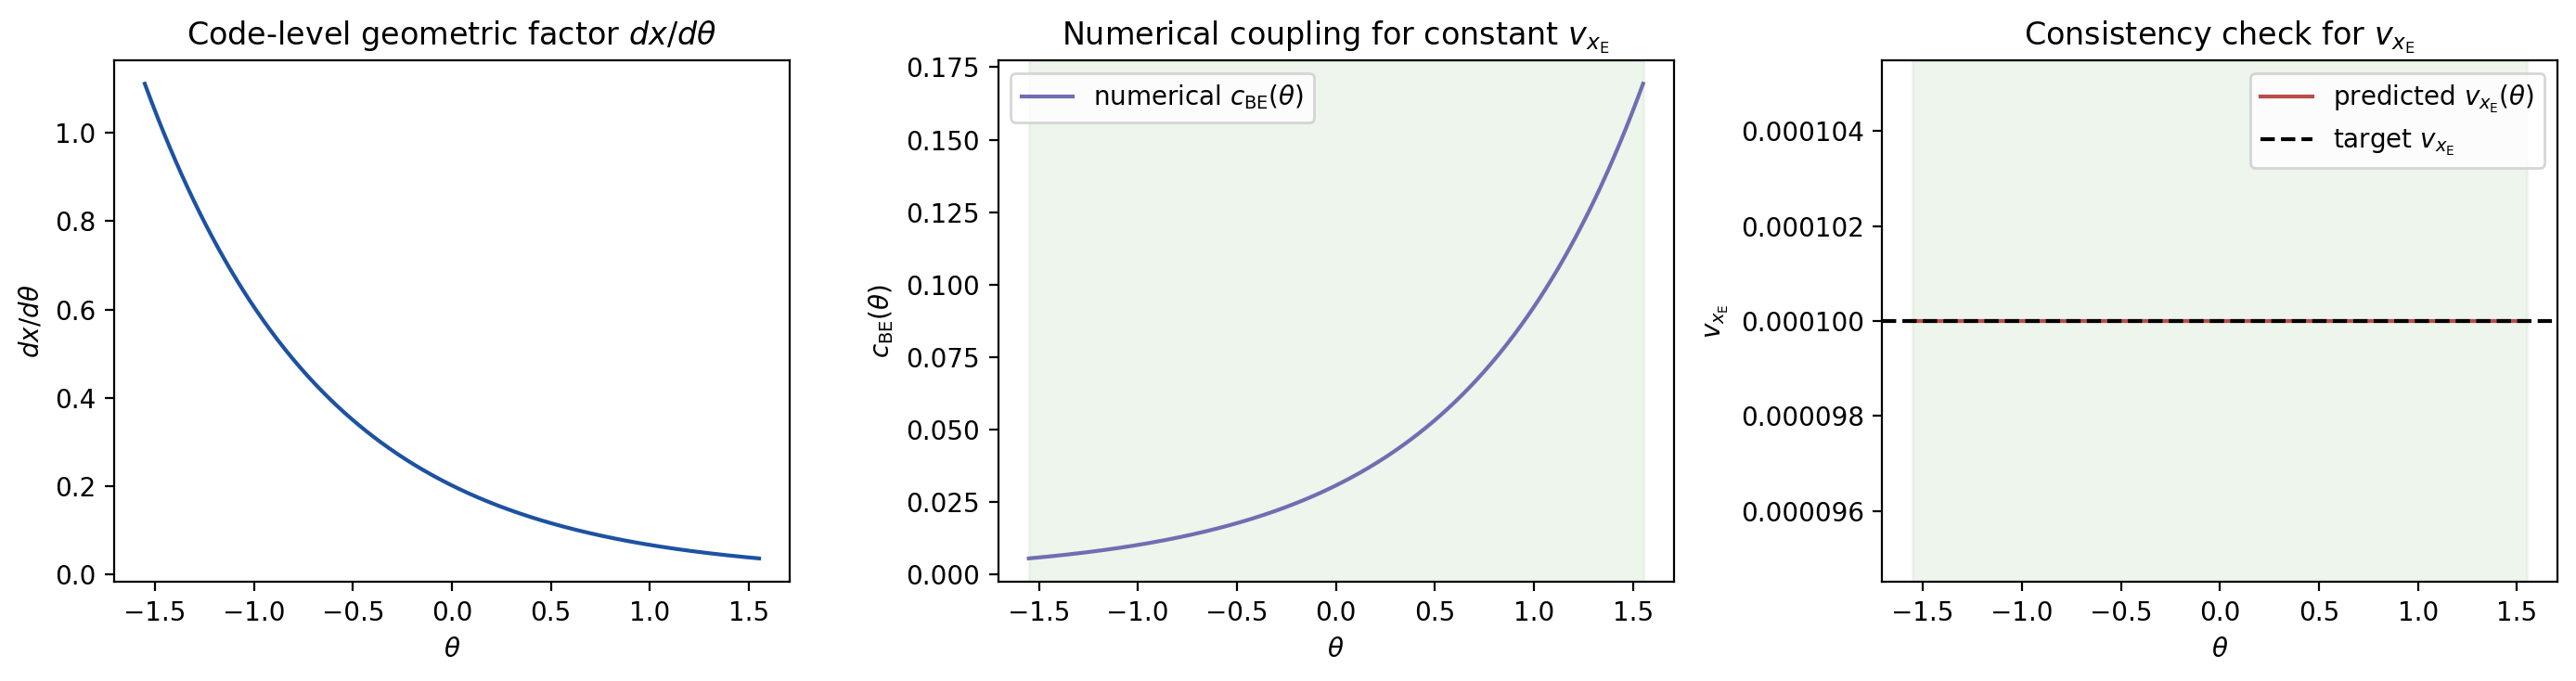

In [22]:
theta_grid = np.linspace(base_model.coding_theta_min + THETA_MARGIN, base_model.coding_theta_max - THETA_MARGIN, 500)
x_grid = np.asarray(base_model.pos_to_evidence(theta_grid, base_model.gamma_E), dtype=float)
theta_min_impl = float(base_model.coding_theta_min)
theta_max_impl = float(base_model.coding_theta_max)
interval_impl = theta_max_impl - theta_min_impl
normalization_impl = 1.0 - np.exp(-GAMMA_THEORY * interval_impl)
dx_dtheta = (
    float(base_model.boundary)
    * GAMMA_THEORY
    * np.exp(-GAMMA_THEORY * (theta_grid - theta_min_impl))
    / normalization_impl
)

c_be_theta_numeric = TARGET_VX / (gain_theta * dx_dtheta)
predicted_v_theta = gain_theta * c_be_theta_numeric
predicted_v_x = predicted_v_theta * dx_dtheta

nearest_sweep_idx = np.abs(c_be_theta_numeric[:, None] - c_be_vals[None, :]).argmin(axis=1)
within_sweep_range = (c_be_theta_numeric >= np.min(c_be_vals)) & (c_be_theta_numeric <= np.max(c_be_vals))
theta_trusted_mask = within_sweep_range & valid_mask[nearest_sweep_idx]
theta_regions = contiguous_true_regions(theta_trusted_mask)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))

ax[0].plot(theta_grid, dx_dtheta, color='#1d52a1')
ax[0].set_xlabel(r'$\theta$')
ax[0].set_ylabel(r'$dx/d\theta$')
ax[0].set_title(r'Code-level geometric factor $dx/d\theta$')

ax[1].plot(theta_grid, c_be_theta_numeric, color='#716db2', label=r'numerical $c_{\mathrm{BE}}(\theta)$')
for start, stop in theta_regions:
    ax[1].axvspan(theta_grid[start], theta_grid[stop], color='#d8ead7', alpha=0.45)
ax[1].set_xlabel(r'$\theta$')
ax[1].set_ylabel(r'$c_{\mathrm{BE}}(\theta)$')
ax[1].set_title(r'Numerical coupling for constant $v_{x_{\mathrm{E}}}$')
ax[1].legend(loc='best')

ax[2].plot(theta_grid, predicted_v_x, color='#b94e48', label=r'predicted $v_{x_{\mathrm{E}}}(\theta)$')
ax[2].axhline(TARGET_VX, color='black', linestyle='--', label=r'target $v_{x_{\mathrm{E}}}$')
for start, stop in theta_regions:
    ax[2].axvspan(theta_grid[start], theta_grid[stop], color='#d8ead7', alpha=0.45)
ax[2].set_xlabel(r'$\theta$')
ax[2].set_ylabel(r'$v_{x_{\mathrm{E}}}$')
ax[2].set_title(r'Consistency check for $v_{x_{\mathrm{E}}}$')
ax[2].legend(loc='best')

plt.tight_layout()

{
    'target_v_x': float(TARGET_VX),
    'trusted_theta_regions': [
        (float(theta_grid[start]), float(theta_grid[stop]))
        for start, stop in theta_regions
    ],
    'numerical_c_BE_min': float(np.min(c_be_theta_numeric)),
    'numerical_c_BE_max': float(np.max(c_be_theta_numeric)),
}


## Step 4: compare the implementation-derived profile to manuscript Eq. 18

The implementation-derived curve above is compared against the manuscript small-signal exponential approximation:

- Eq. 18: the small-signal exponential law

For the notebook comparison:
- the empirical small-signal slope `gain_theta` is used as the effective proportionality constant between $c_{\mathrm{BE}}$ and $d\theta_{\mathrm{E}}/dt$
- the Eq. 18 amplitude is fit on theta points whose required $c_{\mathrm{BE}}(\theta)$ maps to a valid swept point
- the comparison is then shown both on the trusted theta set and across the full theta grid


{'eq18_amplitude_fit': 0.030743886079936056,
 'trusted_theta_point_count': 500,
 'eq18_rmse_trusted': 1.7715128295882954e-17}

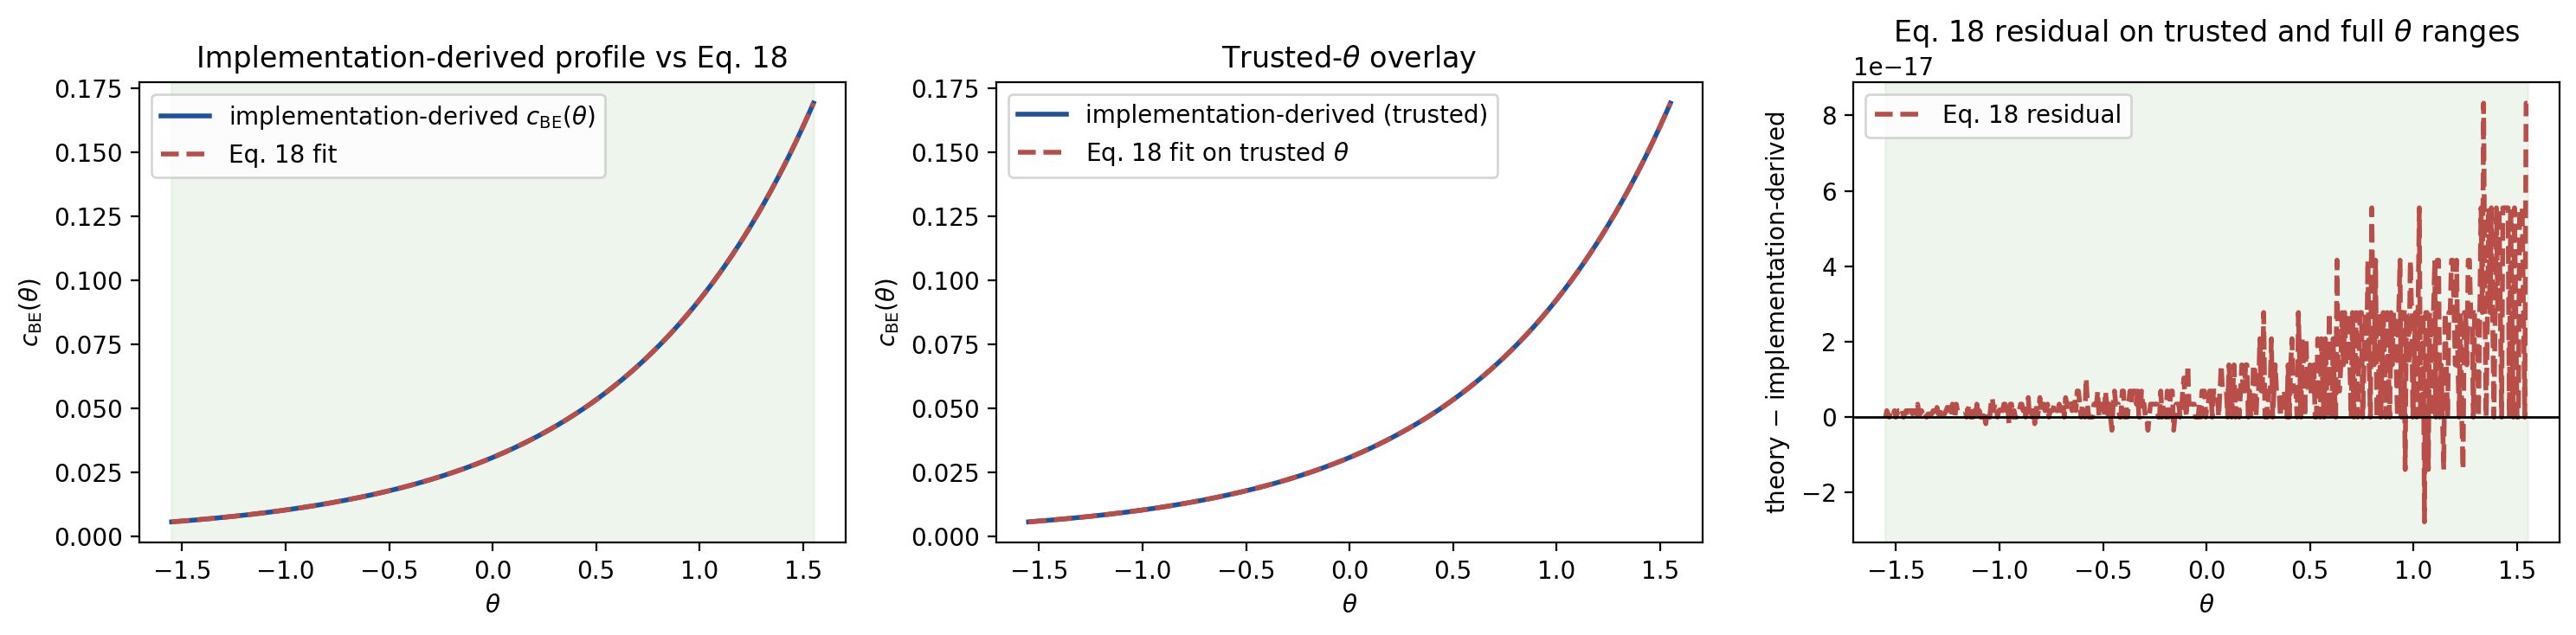

In [23]:
if np.count_nonzero(theta_trusted_mask) >= 5:
    theta_fit = theta_grid[theta_trusted_mask]
    c_fit = c_be_theta_numeric[theta_trusted_mask]
else:
    theta_fit = theta_grid.copy()
    c_fit = c_be_theta_numeric.copy()

amplitude_eq18 = fit_eq18_amplitude(theta_fit, c_fit, gamma_theory=GAMMA_THEORY)

c_eq18 = amplitude_eq18 * np.exp(GAMMA_THEORY * theta_grid)

resid_eq18 = c_eq18 - c_be_theta_numeric

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))

ax[0].plot(theta_grid, c_be_theta_numeric, color='#1d52a1', linewidth=2, label=r'implementation-derived $c_{\mathrm{BE}}(\theta)$')
ax[0].plot(theta_grid, c_eq18, '--', color='#b94e48', linewidth=2, label=r'Eq. 18 fit')
for start, stop in theta_regions:
    ax[0].axvspan(theta_grid[start], theta_grid[stop], color='#d8ead7', alpha=0.45)
ax[0].set_xlabel(r'$\theta$')
ax[0].set_ylabel(r'$c_{\mathrm{BE}}(\theta)$')
ax[0].set_title(r'Implementation-derived profile vs Eq. 18')
ax[0].legend(loc='best')

ax[1].plot(theta_fit, c_fit, color='#1d52a1', linewidth=2, label=r'implementation-derived (trusted)')
ax[1].plot(theta_fit, amplitude_eq18 * np.exp(GAMMA_THEORY * theta_fit), '--', color='#b94e48', linewidth=2, label=r'Eq. 18 fit on trusted $\theta$')
ax[1].set_xlabel(r'$\theta$')
ax[1].set_ylabel(r'$c_{\mathrm{BE}}(\theta)$')
ax[1].set_title(r'Trusted-$\theta$ overlay')
ax[1].legend(loc='best')

ax[2].plot(theta_grid, resid_eq18, '--', color='#b94e48', linewidth=2, label=r'Eq. 18 residual')
ax[2].axhline(0.0, color='black', linewidth=1)
for start, stop in theta_regions:
    ax[2].axvspan(theta_grid[start], theta_grid[stop], color='#d8ead7', alpha=0.45)
ax[2].set_xlabel(r'$\theta$')
ax[2].set_ylabel(r'theory $-$ implementation-derived')
ax[2].set_title(r'Eq. 18 residual on trusted and full $\theta$ ranges')
ax[2].legend(loc='best')

plt.tight_layout()

{
    'eq18_amplitude_fit': float(amplitude_eq18),
    'trusted_theta_point_count': int(np.count_nonzero(theta_trusted_mask)),
    'eq18_rmse_trusted': float(np.sqrt(np.mean((amplitude_eq18 * np.exp(GAMMA_THEORY * theta_fit) - c_fit) ** 2))),
}
